In [3]:
import os
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt


In [4]:
RAW_DATA_PATH = "data/cried_classes"
OUTPUT_PATH = "data/criedClasses_mel_spectrograms"

CLASSES = [
    "0",
    "1",
    "2"
  
]

os.makedirs(OUTPUT_PATH, exist_ok=True)


In [5]:
def save_mel_spectrogram(
    audio_path,
    save_path,
    sr,
    n_mels=60,
    n_fft=512,
    hop_length=160
):
    y, sr = librosa.load(audio_path, sr=sr, mono=True)

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=n_fft,
        hop_length=hop_length,
        n_mels=n_mels
    )

    mel_db = librosa.power_to_db(mel, ref=np.max)

    plt.figure(figsize=(4, 4))
    librosa.display.specshow(
        mel_db,
        sr=sr,
        hop_length=hop_length,
        x_axis="time",
        y_axis="mel"
    )
    plt.axis("off")   # IMPORTANT for CNN
    plt.tight_layout(pad=0)

    plt.savefig(save_path, dpi=150, bbox_inches="tight", pad_inches=0)
    plt.close()


KeyboardInterrupt: 

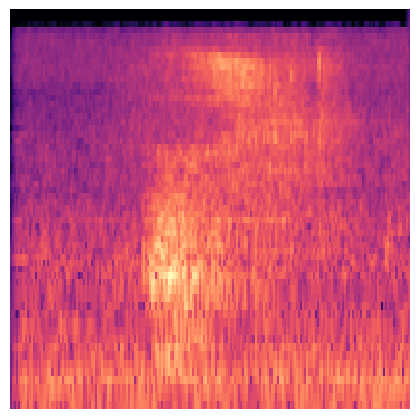

In [7]:
for class_name in CLASSES:
    class_input_path = os.path.join(RAW_DATA_PATH, class_name)
    class_output_path = os.path.join(OUTPUT_PATH, class_name)

    os.makedirs(class_output_path, exist_ok=True)

    for file in os.listdir(class_input_path):
        if file.endswith(".wav"):
            audio_path = os.path.join(class_input_path, file)
            save_path = os.path.join(
                class_output_path,
                file.replace(".wav", ".png")
            )

            save_mel_spectrogram(audio_path, save_path,sr=None)

    print(f"Done for class: {class_name}")


In [ ]:
from PIL import Image
import numpy as np

def mel_image_to_vector(
    image_path,
    img_size=(128, 128)
):
    """
    Convert Mel spectrogram image into a fixed-length vector
    using PIL (no OpenCV required).
    """

    # Load image
    img = Image.open(image_path).convert("L")  # grayscale

    # Resize
    img = img.resize(img_size)

    # Convert to numpy
    img_array = np.array(img)

    # Normalize
    img_array = img_array / 255.0

    # Flatten
    vector = img_array.flatten()

    return vector


In [ ]:
import os

DATASET_PATH = "criedClasses_mel_spectrograms"

CLASSES = [
  "0",
  "1",
  "2"
]

X = []
y = []

for label, class_name in enumerate(CLASSES):
    class_dir = os.path.join(DATASET_PATH, class_name)

    for file in os.listdir(class_dir):
        if file.endswith(".png"):
            img_path = os.path.join(class_dir, file)

            vector = mel_image_to_vector(img_path)

            X.append(vector)
            y.append(label)

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [25]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=20,        # small dataset → small perplexity
    learning_rate=200,
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)

print("t-SNE output shape:", X_tsne.shape)


t-SNE output shape: (5587, 2)


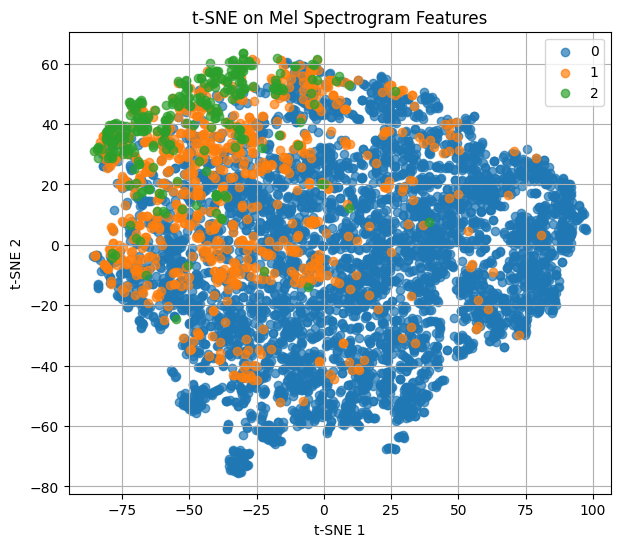

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

for label, class_name in enumerate(CLASSES):
    idx = y == label
    plt.scatter(
        X_tsne[idx, 0],
        X_tsne[idx, 1],
                
        
        label=class_name,
        alpha=0.7
    )

plt.legend()
plt.title("t-SNE on Mel Spectrogram Features")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.grid(True)
plt.show()
